In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [50]:
input_filename = 'cardio_train_properly_separated_comma.csv'
df = pd.read_csv(input_filename, delimiter=',')

In [51]:
df.head(10)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
5,8,21914,1,151,67.0,120,80,2,2,0,0,0,0
6,9,22113,1,157,93.0,130,80,3,1,0,0,1,0
7,12,22584,2,178,95.0,130,90,3,3,0,0,1,1
8,13,17668,1,158,71.0,110,70,1,1,0,0,1,0
9,14,19834,1,164,68.0,110,60,1,1,0,0,0,0


In [52]:
# count null values 
df.isnull().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [53]:
df["age_years"] = (df["age"] / 365).astype(int)
#remove age column


In [54]:
df = df.drop("age", axis=1)

In [55]:
df.head(10)

,id,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
0,0,2,168,62.0,110,80,1,1,0,0,1,0,50
1,1,1,156,85.0,140,90,3,1,0,0,1,1,55
2,2,1,165,64.0,130,70,3,1,0,0,0,1,51
3,3,2,169,82.0,150,100,1,1,0,0,1,1,48
4,4,1,156,56.0,100,60,1,1,0,0,0,0,47
5,8,1,151,67.0,120,80,2,2,0,0,0,0,60
6,9,1,157,93.0,130,80,3,1,0,0,1,0,60
7,12,2,178,95.0,130,90,3,3,0,0,1,1,61
8,13,1,158,71.0,110,70,1,1,0,0,1,0,48
9,14,1,164,68.0,110,60,1,1,0,0,0,0,54


In [56]:
# Add BMI
df["bmi"] = df["weight"] / (df["height"]/100)**2

In [57]:
df.head(10)

,id,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi
0,0,2,168,62.0,110,80,1,1,0,0,1,0,50,21.967120
1,1,1,156,85.0,140,90,3,1,0,0,1,1,55,34.927679
2,2,1,165,64.0,130,70,3,1,0,0,0,1,51,23.507805
3,3,2,169,82.0,150,100,1,1,0,0,1,1,48,28.710479
4,4,1,156,56.0,100,60,1,1,0,0,0,0,47,23.011177
5,8,1,151,67.0,120,80,2,2,0,0,0,0,60,29.384676
6,9,1,157,93.0,130,80,3,1,0,0,1,0,60,37.729725
7,12,2,178,95.0,130,90,3,3,0,0,1,1,61,29.983588
8,13,1,158,71.0,110,70,1,1,0,0,1,0,48,28.440955
9,14,1,164,68.0,110,60,1,1,0,0,0,0,54,25.282570


In [58]:
print("Min height:", df["height"].min())
print("Max height:", df["height"].max())

print("Min weight:", df["weight"].min())
print("Max weight:", df["weight"].max())


Min height: 55
Max height: 250
Min weight: 10.0
Max weight: 200.0


In [59]:
# Clean height
df = df[(df["height"] >= 130) & (df["height"] <= 220)]

# Clean weight
df = df[(df["weight"] >= 30) & (df["weight"] <= 200)]


In [60]:
print("Min height:", df["height"].min())
print("Max height:", df["height"].max())

print("Min weight:", df["weight"].min())
print("Max weight:", df["weight"].max())


Min height: 130
Max height: 207
Min weight: 30.0
Max weight: 200.0


In [61]:
df['ap_hi'].min(), df['ap_hi'].max()
df['ap_lo'].min(), df['ap_lo'].max()


(-70, 11000)

In [62]:
df = df[(df["ap_hi"] > 0) & (df["ap_lo"] > 0)]

In [63]:
df['ap_hi'].min(), df['ap_hi'].max()
df['ap_lo'].min(), df['ap_lo'].max()

(1, 11000)

In [64]:
df = df[(df["ap_hi"] >= 80) & (df["ap_hi"] <= 250)]
df = df[(df["ap_lo"] >= 40) & (df["ap_lo"] <= 200)]

In [65]:
df['ap_hi'].min(), df['ap_hi'].max()
df['ap_lo'].min(), df['ap_lo'].max()


(40, 190)

In [66]:
df["cholesterol"].unique()


array([1, 3, 2])

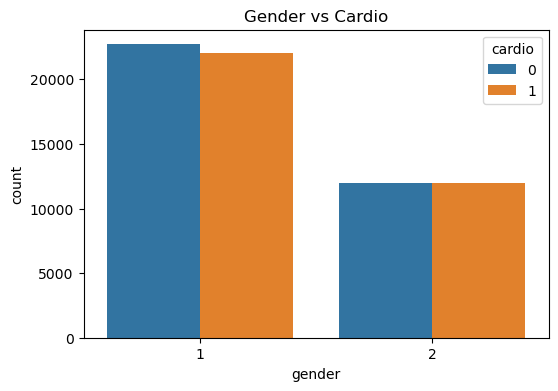

In [67]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender', hue='cardio', data=df)
plt.title("Gender vs Cardio")
plt.show()

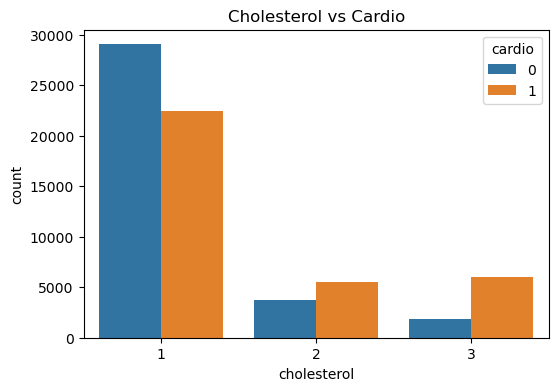

In [68]:
plt.figure(figsize=(6,4))
sns.countplot(x='cholesterol', hue='cardio', data=df)
plt.title("Cholesterol vs Cardio")
plt.show()

<h3>Gender vs Cardio</h3>
<p>
The bar chart compares heart disease occurrence between genders.
In this dataset, gender does not show any strong influence on heart disease.
Both males and females have almost the same ratio of cardio cases.
Therefore, gender is not a significant predictor of heart disease.
</p>


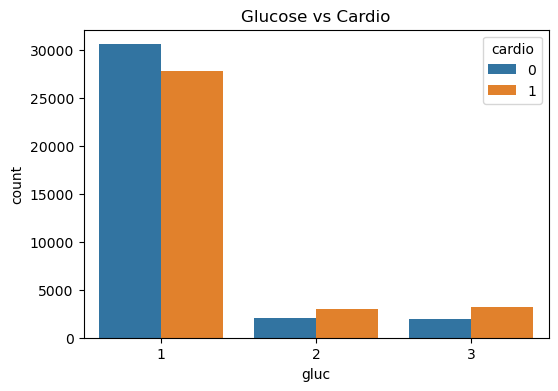

In [69]:
plt.figure(figsize=(6,4))
sns.countplot(x='gluc', hue='cardio', data=df)
plt.title("Glucose vs Cardio")
plt.show()

<h3>Glucose vs Cardio</h3>
<p>
This chart shows the relationship between glucose levels and heart disease.
Most people in the dataset have normal glucose levels (gluc = 1), and among them,
cardio cases are slightly fewer compared to non-cardio.
However, when glucose levels increase to 2 or 3, the number of cardio cases becomes higher.
This indicates that elevated glucose levels are associated with a higher risk of heart disease.
Although not the strongest factor, glucose is still a meaningful predictor.
</p>


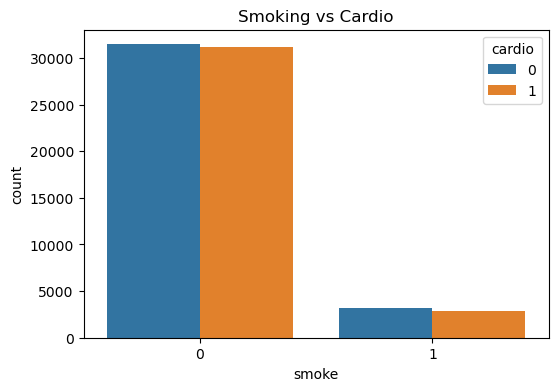

In [70]:
plt.figure(figsize=(6,4))
sns.countplot(x='smoke', hue='cardio', data=df)
plt.title("Smoking vs Cardio")
plt.show()

<h3>Smoking vs Cardio</h3>
<p>
This chart compares smoking status with the occurrence of heart disease. 
Most people in the dataset are non-smokers, and among them, the number of cardio and non-cardio cases is almost the same. 
For smokers, both cardio and non-cardio counts are lower due to fewer smokers in the dataset. 
Overall, smoking does not show a strong relationship with heart disease in this dataset, 
which is also confirmed by the very low correlation value in the heatmap.
</p>


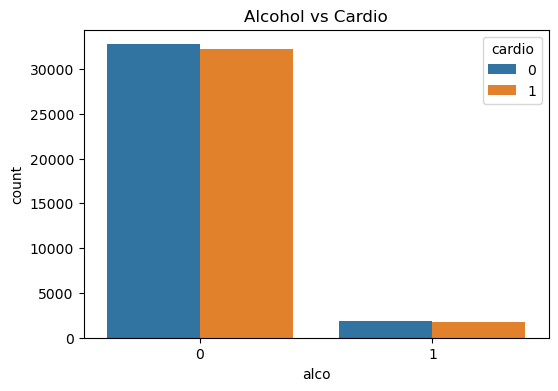

In [71]:
plt.figure(figsize=(6,4))
sns.countplot(x='alco', hue='cardio', data=df)
plt.title("Alcohol vs Cardio")
plt.show()

<h3>Alcohol vs Cardio</h3>
<p>
This chart shows the comparison between alcohol consumption and heart disease.
Most people in the dataset do not drink alcohol, and for them, the number of cardio and 
non-cardio cases is almost the same. Among alcohol drinkers, the number of cases is much smaller,
and both categories (cardio and non-cardio) also appear nearly equal.
Overall, alcohol consumption does not show a strong relationship with heart disease in this dataset,
which is confirmed by the very low correlation value between alcohol and cardio.
</p>


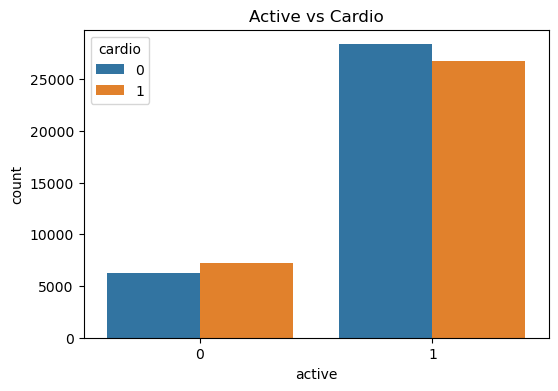

In [72]:
plt.figure(figsize=(6,4))
sns.countplot(x='active', hue='cardio', data=df)
plt.title("Active vs Cardio")
plt.show()

Before: 68664 After: 68568


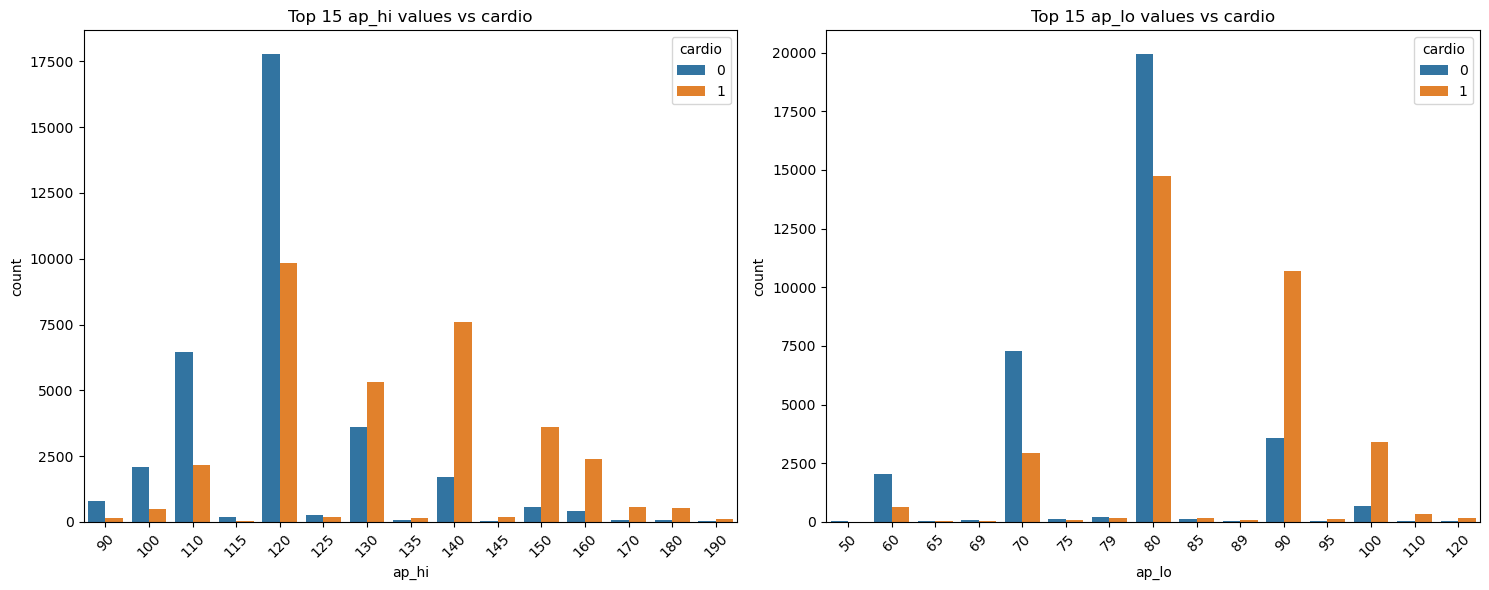

In [73]:
#ap high low , vs cardio 
# CODE: cleaning function (adapt from earlier)
AP_HI_MIN, AP_HI_MAX = 70, 250
AP_LO_MIN, AP_LO_MAX = 40, 140

def clean_bp(df):
    df = df.copy()
    df = df.dropna(subset=['ap_hi','ap_lo','cardio'])
    df['ap_hi'] = df['ap_hi'].astype(int)
    df['ap_lo'] = df['ap_lo'].astype(int)
    mask = (
        (df['ap_hi'] >= AP_HI_MIN) & (df['ap_hi'] <= AP_HI_MAX) &
        (df['ap_lo'] >= AP_LO_MIN) & (df['ap_lo'] <= AP_LO_MAX)
    )
    df = df[mask]
    df = df[df['ap_lo'] <= df['ap_hi']]
    return df

df_clean = clean_bp(df)
print("Before:", len(df), "After:", len(df_clean))

top_hi = df_clean['ap_hi'].value_counts().nlargest(15).index
top_lo = df_clean['ap_lo'].value_counts().nlargest(15).index

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.countplot(x='ap_hi', hue='cardio', data=df_clean[df_clean['ap_hi'].isin(top_hi)])
plt.title('Top 15 ap_hi values vs cardio')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.countplot(x='ap_lo', hue='cardio', data=df_clean[df_clean['ap_lo'].isin(top_lo)])
plt.title('Top 15 ap_lo values vs cardio')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


<h3>Active vs Cardio</h3>
<p>
This chart shows the comparison between physical activity and heart disease.
Most people in the dataset are physically active. Among active individuals,
the number of non-cardio cases is slightly higher than cardio cases,
indicating a small reduction in heart disease risk for active people.
For non-active individuals, cardio cases are slightly higher.
However, the difference is small, meaning that physical activity has only
a minor effect on heart disease risk in this dataset.
This is consistent with the very weak negative correlation between activity and cardio.
</p>


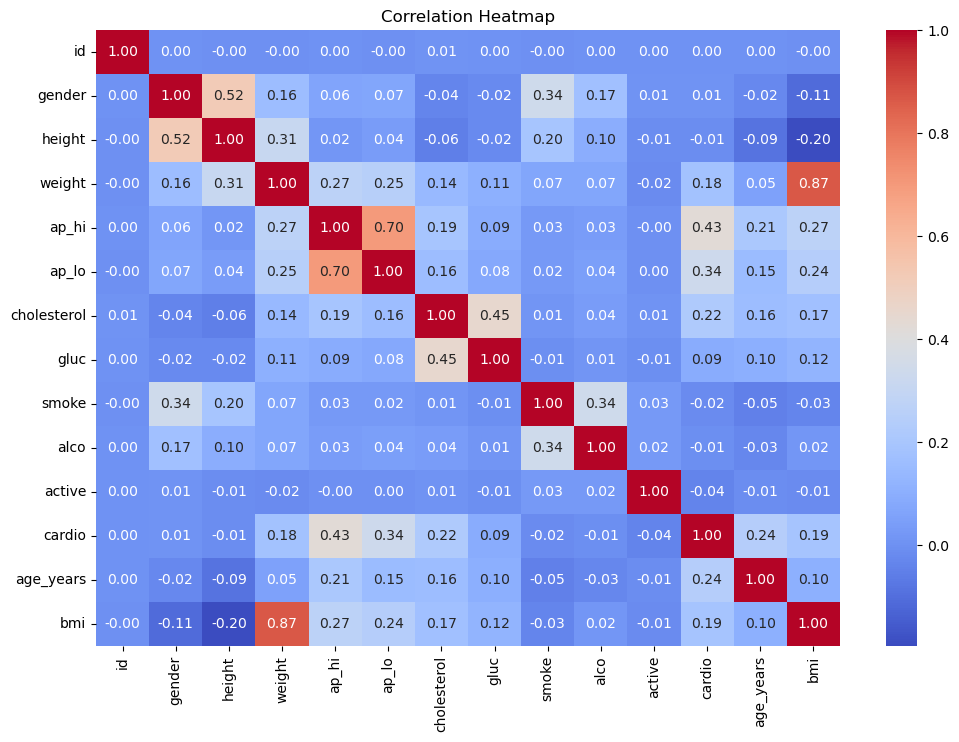

In [74]:
# Heatmap of correlations
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


<h2>Correlation Heatmap Analysis</h2>

<p>The heatmap shows the relationship between different health parameters and the cardio (heart disease) outcome.</p>

<h3>Top Predictors of Heart Disease</h3>
<ul>
  <li><strong>Systolic Blood Pressure (ap_hi): 0.43</strong> – The strongest predictor. Higher systolic BP increases the risk of heart disease.</li>
  <li><strong>Age: 0.24</strong> – Older individuals have a higher risk.</li>
  <li><strong>Cholesterol: 0.22</strong> – High cholesterol levels contribute significantly to heart disease.</li>
</ul>

<h3>Moderate Predictors</h3>
<ul>
  <li><strong>BMI: 0.19</strong> – Overweight individuals show a higher chance of having cardio.</li>
  <li><strong>Weight: 0.18</strong> – Correlated with BMI.</li>
  <li><strong>Diastolic BP (ap_lo): 0.15</strong> – Plays a role but weaker than systolic.</li>
</ul>

<h3>Weak or No Effect</h3>
<ul>
  <li><strong>Gender, Smoking, Alcohol, Activity, Height</strong> – Very low correlation, meaning they do not significantly affect heart disease in this dataset.</li>
</ul>


In [75]:
#scatter plot of all the features
# X = df.drop("", axis=1)
# y = df["cardio"]
# sns.pairplot(df, hue="cardio")
# plt.show()

#correlation matrix
correlation_matrix = df.corr()
print(correlation_matrix)

                   id    gender    height    weight     ap_hi     ap_lo  \
id           1.000000  0.002856 -0.002342 -0.001742  0.001159 -0.000486   
gender       0.002856  1.000000  0.521938  0.157103  0.061528  0.066585   
height      -0.002342  0.521938  1.000000  0.311073  0.017348  0.035138   
weight      -0.001742  0.157103  0.311073  1.000000  0.268612  0.249351   
ap_hi        0.001159  0.061528  0.017348  0.268612  1.000000  0.700664   
ap_lo       -0.000486  0.066585  0.035138  0.249351  0.700664  1.000000   
cholesterol  0.005963 -0.036509 -0.055395  0.141339  0.194027  0.158973   
gluc         0.002413 -0.021082 -0.020975  0.106991  0.092983  0.076495   
smoke       -0.003282  0.338811  0.196067  0.066986  0.027246  0.024379   
alco         0.000631  0.171291  0.098240  0.068382  0.033134  0.042959   
active       0.003904  0.005906 -0.009580 -0.017841 -0.001816  0.000153   
cardio       0.003540  0.007268 -0.012365  0.179883  0.425140  0.335852   
age_years    0.003805 -0.

In [76]:
# Calculate correlation matrix ensuring numeric columns only
numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()


In [77]:
strong_predictors = correlation_matrix["cardio"].abs().sort_values(ascending=False)[1:]
print(strong_predictors)

ap_hi          0.425140
ap_lo          0.335852
age_years      0.239364
cholesterol    0.221430
bmi            0.191246
weight         0.179883
gluc           0.090010
active         0.037424
smoke          0.016193
height         0.012365
alco           0.007788
gender         0.007268
id             0.003540
Name: cardio, dtype: float64


## 3. Model Creation

### 3.1 Selection of Algorithm
Logistic Regression is chosen as the target variable (cardio) is binary.
The model is implemented from scratch without using any machine learning library.


In [78]:
import numpy as np

# Feature selection
X = df[['ap_hi', 'ap_lo', 'age_years', 'cholesterol', 'bmi', 'weight']]
y = df['cardio']
X_np = X.values          # features
y_np = y.values.reshape(-1, 1)  # labels


In [79]:
split_ratio = 0.8
split_index = int(len(X_np) * split_ratio)

X_train = X_np[:split_index]
X_test  = X_np[split_index:]

y_train = y_np[:split_index]
y_test  = y_np[split_index:]


In [80]:
X_train = (X_train - X_train.mean(axis=0)) / X_train.std(axis=0)
X_test  = (X_test - X_test.mean(axis=0)) / X_test.std(axis=0)


In [81]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [82]:
m, n = X_train.shape
weights = np.zeros((n, 1))
bias = 0
learning_rate = 0.01
epochs = 1000


In [83]:
for _ in range(epochs):
    z = np.dot(X_train, weights) + bias
    y_pred = sigmoid(z)

    dw = (1/m) * np.dot(X_train.T, (y_pred - y_train))
    db = (1/m) * np.sum(y_pred - y_train)

    weights -= learning_rate * dw
    bias -= learning_rate * db


In [84]:
def predict(X):
    z = np.dot(X, weights) + bias
    return (sigmoid(z) >= 0.5).astype(int)


In [85]:
y_pred = predict(X_test)
accuracy = np.mean(y_pred == y_test)
print("Accuracy (Logistic Regression ):", accuracy)


Accuracy (Logistic Regression ): 0.7203815626592879


In [86]:
#split data into training and testing sets
X = df[strong_predictors.index]
y = df["cardio"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#train a random forest classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [87]:
#make predictions on the test set
y_pred = rf.predict(X_test)

In [88]:

#evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.7208184664676327
Precision: 0.7259169076244103
Recall: 0.701161252388652
F1 Score: 0.7133243606998654


In [89]:

#feature importance
importance = pd.DataFrame({"feature": strong_predictors.index, "importance": rf.feature_importances_})
print(importance.sort_values(by="importance", ascending=False))
# plt.show()

        feature  importance
12           id    0.176846
0         ap_hi    0.163340
4           bmi    0.145801
2     age_years    0.121954
5        weight    0.108879
9        height    0.103913
1         ap_lo    0.083421
3   cholesterol    0.036714
11       gender    0.015949
6          gluc    0.015445
7        active    0.013143
8         smoke    0.007941
10         alco    0.006652


## Random Forest: Baseline vs Tuned (Concise)
Minimal, easy-to-read comparison of two Random Forest models on the cleaned cardio dataset.
- Baseline: default settings (quick reference)
- Tuned: simple improved settings (better generalization)
- Outputs: core metrics + quick comparison + saved models

In [90]:
# Quick setup: use existing train/test splits (X_train, X_test, y_train, y_test)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Training samples:", len(X_train), "| Test samples:", len(X_test))
print("Features:", list(X_train.columns))


Training samples: 54931 | Test samples: 13733
Features: ['ap_hi', 'ap_lo', 'age_years', 'cholesterol', 'bmi', 'weight', 'gluc', 'active', 'smoke', 'height', 'alco', 'gender', 'id']


Baseline Random Forest

In [91]:
# Baseline Random Forest (simple defaults)
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
)
rf_baseline.fit(X_train, y_train)

y_pred_base = rf_baseline.predict(X_test)
y_prob_base = rf_baseline.predict_proba(X_test)[:, 1]

baseline_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_base),
    "precision": precision_score(y_test, y_pred_base),
    "recall": recall_score(y_test, y_pred_base),
    "f1": f1_score(y_test, y_pred_base),
    "roc_auc": roc_auc_score(y_test, y_prob_base),
}
print("Baseline metrics:", baseline_metrics)


Baseline metrics: {'accuracy': 0.7208184664676327, 'precision': 0.7259169076244103, 'recall': 0.701161252388652, 'f1': 0.7133243606998654, 'roc_auc': 0.7826173157203584}


Tuned Random Forest

In [92]:
# Tuned Random Forest 
rf_tuned = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1,
)
rf_tuned.fit(X_train, y_train)

y_pred_tuned = rf_tuned.predict(X_test)
y_prob_tuned = rf_tuned.predict_proba(X_test)[:, 1]

tuned_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_tuned),
    "precision": precision_score(y_test, y_pred_tuned),
    "recall": recall_score(y_test, y_pred_tuned),
    "f1": f1_score(y_test, y_pred_tuned),
    "roc_auc": roc_auc_score(y_test, y_prob_tuned),
}
print("Tuned metrics:", tuned_metrics)


Tuned metrics: {'accuracy': 0.7331974077040705, 'precision': 0.7591216773980518, 'recall': 0.6758782889901515, 'f1': 0.7150855365474339, 'roc_auc': 0.8005714205111529}


In [93]:
# Side-by-side comparison
import pandas as pd

comparison = pd.DataFrame({"Baseline": baseline_metrics, "Tuned": tuned_metrics})
comparison["Improvement"] = comparison["Tuned"] - comparison["Baseline"]
print(comparison)


           Baseline     Tuned  Improvement
accuracy   0.720818  0.733197     0.012379
precision  0.725917  0.759122     0.033205
recall     0.701161  0.675878    -0.025283
f1         0.713324  0.715086     0.001761
roc_auc    0.782617  0.800571     0.017954


In [94]:
# Save models for API use
import joblib
from pathlib import Path

artifacts = Path("artifacts")
artifacts.mkdir(exist_ok=True)

joblib.dump(rf_baseline, artifacts / "random_forest_baseline_final.joblib")
joblib.dump(rf_tuned, artifacts / "best_random_forest_tuned_final.joblib")
print("Saved models to", artifacts.resolve())


Saved models to D:\ML\Project ML\artifacts
